In [61]:
url = 'https://raw.githubusercontent.com/dana-fatemeh/Final-ML-Project/main/Data/train.csv'

# Import everything we need for the project in one place
try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import optuna as tuna
    import copy
    
except ImportError:
    print("Installing requisit packages...")
    
    %pip install -q matplotlib
    %pip install -q pandas
    %pip install -q numpy
    %pip install -q seaborn
    %pip install -q optuna

    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import optuna as tuna
    import copy


data = pd.read_csv(url)

pd.set_option('display.max_colwidth', None) # Don't cut off text inside cells
pd.set_option('display.max_columns', 300) # shows all the columns
pd.set_option('display.expand_frame_repr', False) # Don't wrap to new lines
data


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

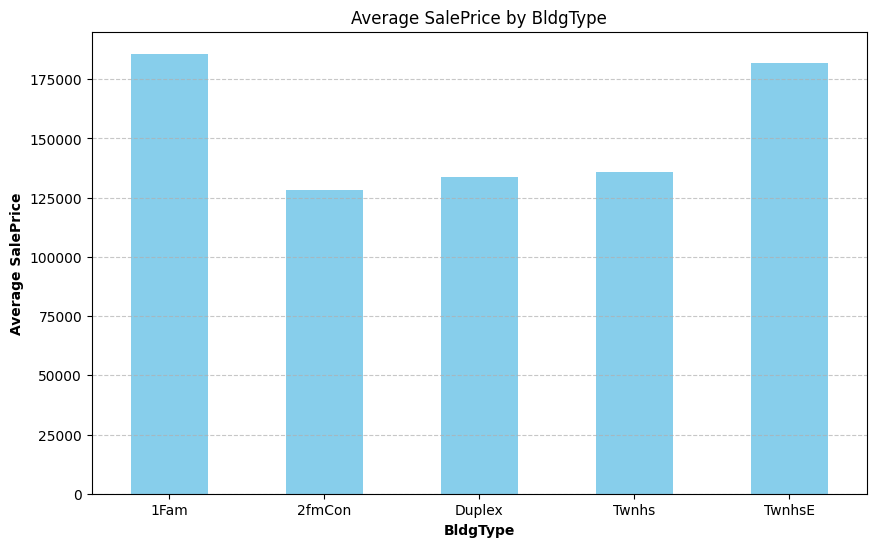

<Figure size 600x300 with 0 Axes>

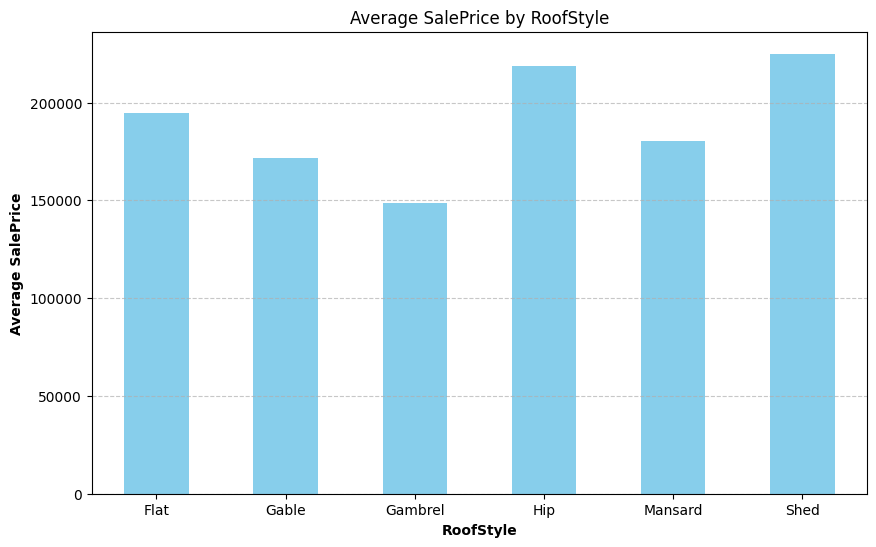

<Figure size 600x300 with 0 Axes>

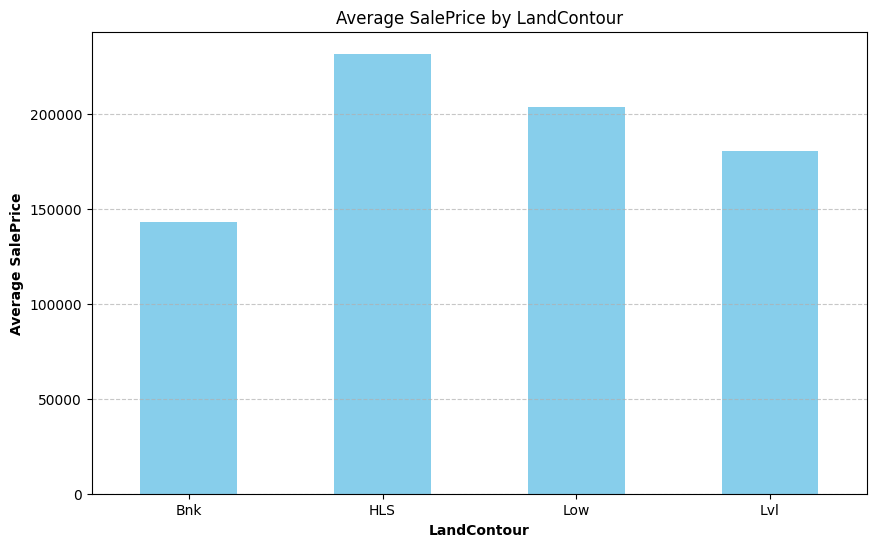

<Figure size 600x300 with 0 Axes>

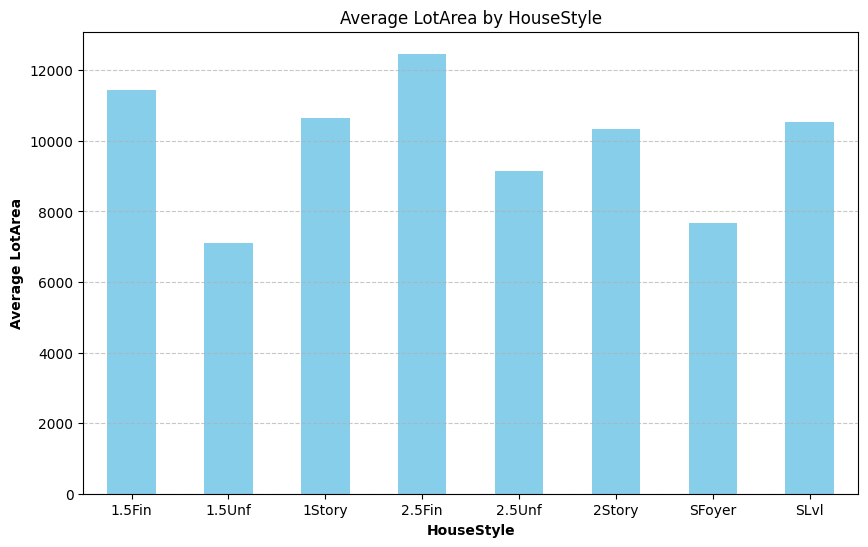

<Figure size 600x300 with 0 Axes>

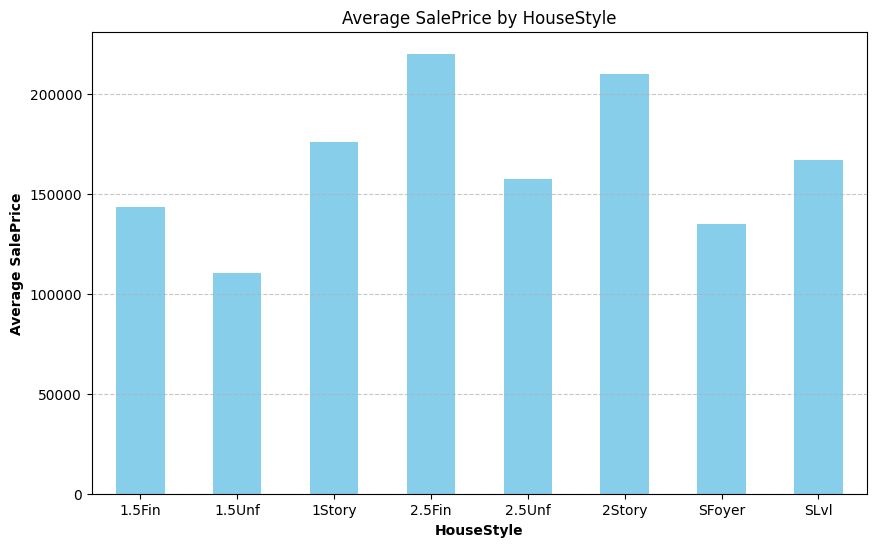

<Figure size 600x300 with 0 Axes>

Text(0.5, 1.02, 'SalePrice linear regression relationship with LotArea')

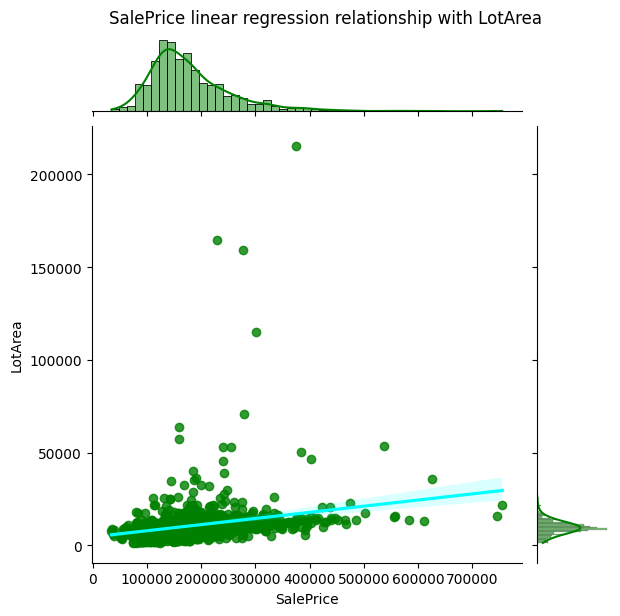

In [62]:
# Plots to make better guesses on ordinal data selection:

def ordinal_plot(ord_feat_name : str, num_feat_name : str):
    avg_price_by_feature = data.groupby(ord_feat_name)[num_feat_name].mean()
    avg_price_by_feature.plot.bar(figsize=(10, 6), color='skyblue', rot=0)

    plt.title(f'Average {num_feat_name} by {ord_feat_name}')
    plt.xlabel(f'{ord_feat_name}', fontweight='bold')
    plt.ylabel(f'Average {num_feat_name}', fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.figure(figsize=(6, 3))
    plt.tight_layout()
    plt.show()

ordinal_plot("BldgType",'SalePrice')
ordinal_plot('RoofStyle','SalePrice')
ordinal_plot('LandContour','SalePrice')
ordinal_plot('HouseStyle','LotArea')
ordinal_plot('HouseStyle','SalePrice')

plot1 = sns.jointplot(x='SalePrice',y='LotArea',data=data,kind="reg",color="green", joint_kws={'line_kws':{'color':'cyan'}})
plot1.figure.suptitle("SalePrice linear regression relationship with LotArea", y=1.02)


In [63]:
# --- FEATURE ENGINEERING CELL: ---

# Droppings some "low hanging fruit" features:
data = data.drop(columns=['Id'])
data['Has_Alley'] = data['Alley'].notna().astype(int)
data = data.drop(columns=['Alley'])
data = data.drop(columns=['Utilities']) # Maybe Ordinal


# ---- SOME FEATURE INFORMATION: ----
# 
# MasVnrType: Masonry veneer type
# BsmtQual: Evaluates the height of the basement
# BsmtCond: Evaluates the general condition of the basement
# BsmtExposure: Refers to walkout or garden level walls
# BsmtFinType1: Rating of basement finished area
# BsmtFinType2: Rating of basement finished area (if multiple types)
# FireplaceQu: Fireplace quality
# GarageType: Garage location
# GarageFinish: Interior finish of the garage
# GarageQual: Garage quality
# GarageCond: Garage condition
# PoolQC: Pool quality
# Fence: Fence quality
# MiscFeature: Miscellaneous feature not covered in other categories
#
# -----------------------------------

# Converting missing 'NaN' values to 'None' or '0' where applicable:
none_cols = ['MasVnrType','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature']
for col in none_cols:
    data[col] = data[col].fillna('None')

data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)
data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)
data['Electrical'] = data['Electrical'].fillna(0)
data['LotFrontage'] = data['LotFrontage'].fillna(0)
data['MasVnrArea'] = data['MasVnrArea'].fillna(0)


# Ordinal data encoding:
qual_rate = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0} # Maybe change None to -1
ord_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']
for col in ord_cols:
    data[col+'_ord'] = data[col].map(qual_rate)
    data = data.drop(columns=[col])

data['LandContour'] = data['LandContour'].map({'Lvl':2, 'Bnk':1, 'HLS':4, 'Low':3}) # Maybe Change
data['LandSlope'] = data['LandSlope'].map({'Gtl':1, 'Mod':2, 'Sev':5})
data['BsmtExposure'] = data['BsmtExposure'].map({'Gd':10, 'Av':6, 'Mn':3, 'No':1, 'None':0})
data['BsmtFinType1'] = data['BsmtFinType1'].map({'GLQ':10, 'ALQ':7, 'BLQ':3, 'Rec':5, 'LwQ':2, 'Unf':1, 'None':0})
data['BsmtFinType2'] = data['BsmtFinType2'].map({'GLQ':10, 'ALQ':7, 'BLQ':3, 'Rec':5, 'LwQ':2, 'Unf':1, 'None':0})
data['CentralAir'] = data['CentralAir'].map({'Y':1, 'N':0})
data['Electrical'] = data['Electrical'].map({'SBrkr':10, 'FuseA':7, 'FuseF':3, 'FuseP':1, 'Mix':5})
data['Functional'] = data['Functional'].map({'Typ':10, 'Min1':9, 'Min2':8, 'Mod':5, 'Maj1':3, 'Maj2':2, 'Sev':1, 'Sal':0})
data['GarageFinish'] = data['GarageFinish'].map({'Fin':5, 'RFn':2, 'Unf':1, 'None':0})
data['Fence'] = data['Fence'].map({'GdPrv':5, 'MnPrv':3, 'GdWo':2, 'MnWw':1, 'None':0})

data['BldgType'] = data['BldgType'].map({'1Fam':10, '2fmCon':6, 'Duplex':7, 'Twnhs':7, 'TwnhsE':9})
data['RoofStyle'] = data['RoofStyle'].map({'Flat':7,'Gable':5, 'Gambrel':3, 'Hip':9, 'Mansard':6, 'Shed':10})


# One-Hot-encoded categorical features:
categorical_cols = ['MSZoning','Street','LotShape','LotConfig','Neighborhood',
                'Condition1','Condition2','HouseStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType',
                'Foundation','Heating','CentralAir','GarageType','PavedDrive','MiscFeature',
                'SaleType','SaleCondition']
# NOTE - Features I've swapped to Ordinal in this branch: ,'BldgType','RoofStyle'

data = pd.get_dummies(data, columns=[col for col in categorical_cols], dtype=int)


# Engineered features combinations: 
data['TotalBathrooms'] = data['FullBath'] + 0.5*data['HalfBath'] + data['BsmtFullBath'] + 0.5*data['BsmtHalfBath']
data['Age'] = 2009 - data['YearBuilt']
data['RemodAge'] = 2009 - data['YearRemodAdd']
data['IsRemodeled'] = (data['YearBuilt'] != data['YearRemodAdd']).astype(int)
data['GoodTotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['WoodDeckSF'] + data['OpenPorchSF'] + data['2ndFlrSF'] - data['LowQualFinSF']
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF'] + data['WoodDeckSF'] + data['OpenPorchSF']


# Displays Final engineered data:
pd.set_option('display.max_colwidth', None) # Don't cut off text inside cells
pd.set_option('display.max_columns', 300) # shows all the columns
pd.set_option('display.expand_frame_repr', False) # Don't wrap to new lines
data

,MSSubClass,LotFrontage,LotArea,LandContour,LandSlope,BldgType,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,MasVnrArea,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Functional,Fireplaces,GarageYrBlt,GarageFinish,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SalePrice,Has_Alley,ExterQual_ord,ExterCond_ord,BsmtQual_ord,BsmtCond_ord,HeatingQC_ord,KitchenQual_ord,FireplaceQu_ord,GarageQual_ord,GarageCond_ord,PoolQC_ord,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_0,CentralAir_1,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,PavedDrive_N,PavedDrive_P,PavedDrive_Y,MiscFeature_Gar2,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,TotalBathrooms,Age,RemodAge,IsRemodeled,GoodTotalSF,TotalSF
0,60,65.0,8450,2,1,10,7,5,2003,2003,5,196.0,1,10,706,1,0,150,856,10.0,856,854,0,1710,1,0,2,1,3,1,8,10,0,2003.0,2,2,548,0,61,0,0,0,0,0,0,2,2008,208500,0,4,3,4,3,5,4,0,3,3,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,3.5,6,6,0,2627,2627
1,20,80.0,9600,2,1,10,6,8,1976,1976,5,0.0,10,7,978,1,0,284,1262,10.0,1262,0,0,1262,0,1,2,0

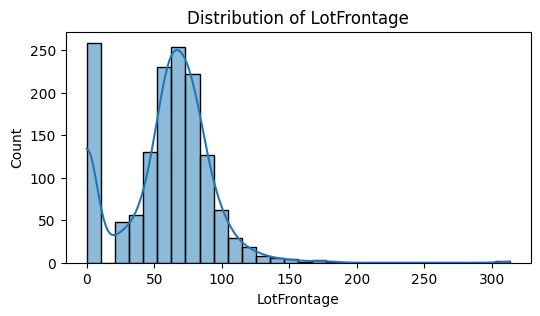

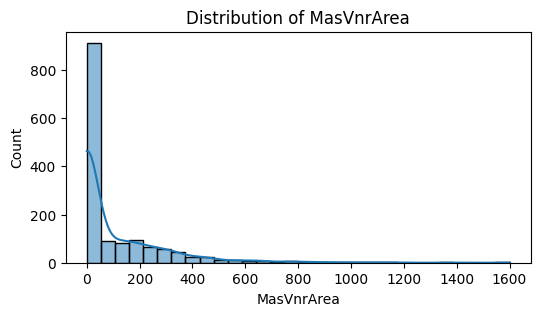

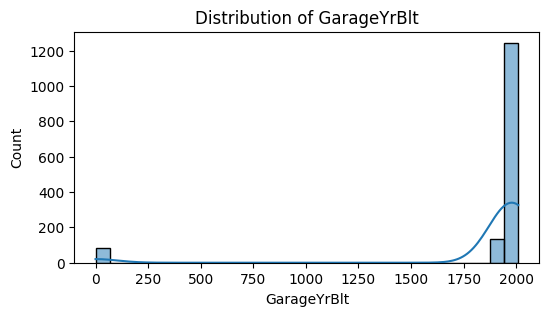

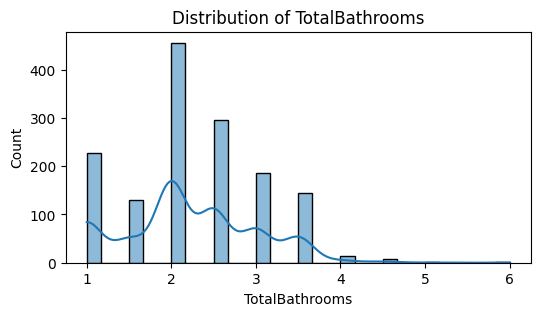

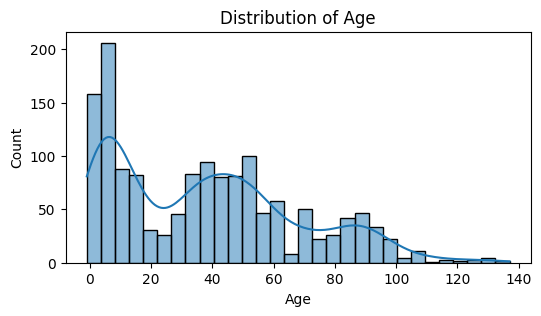

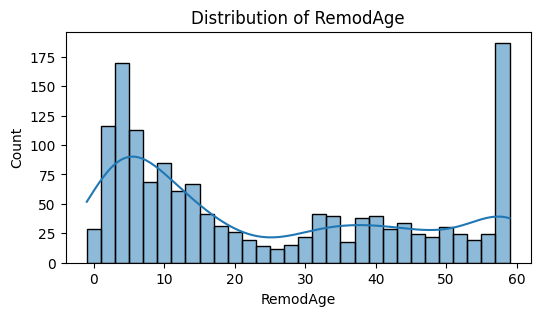

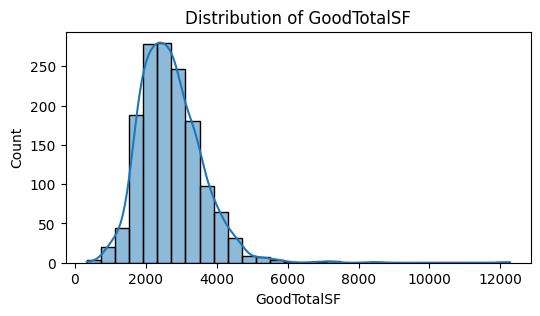

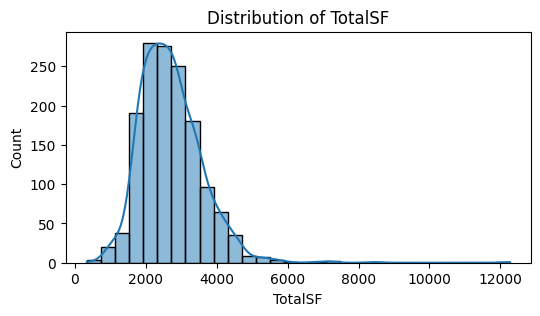

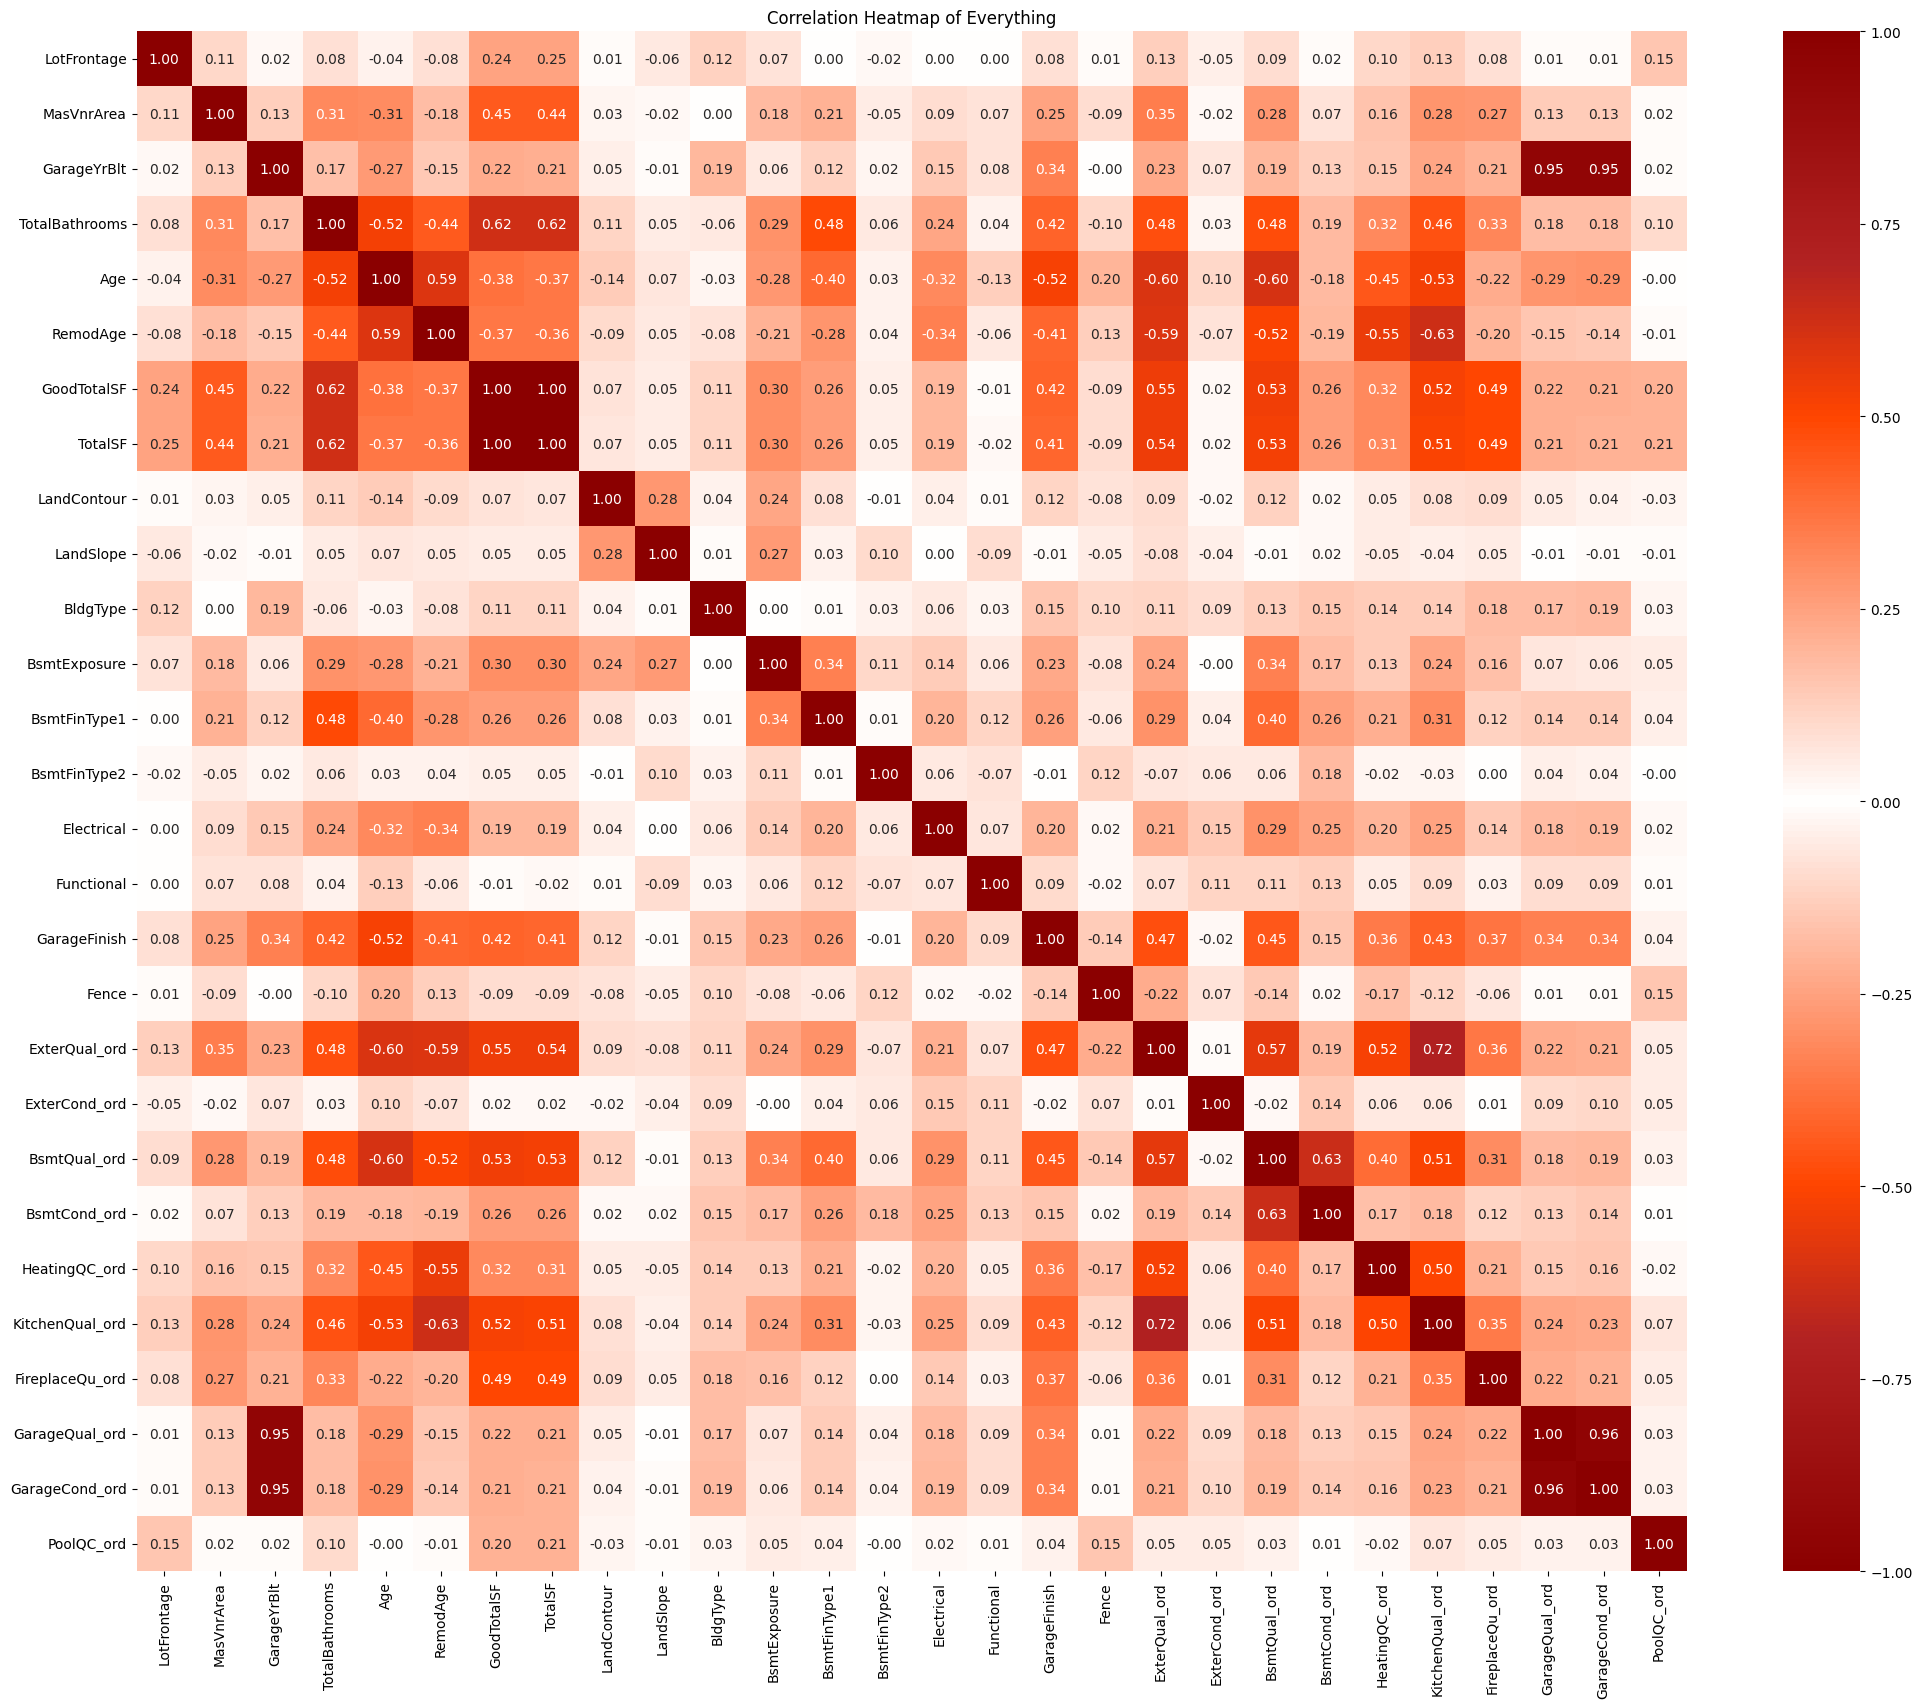

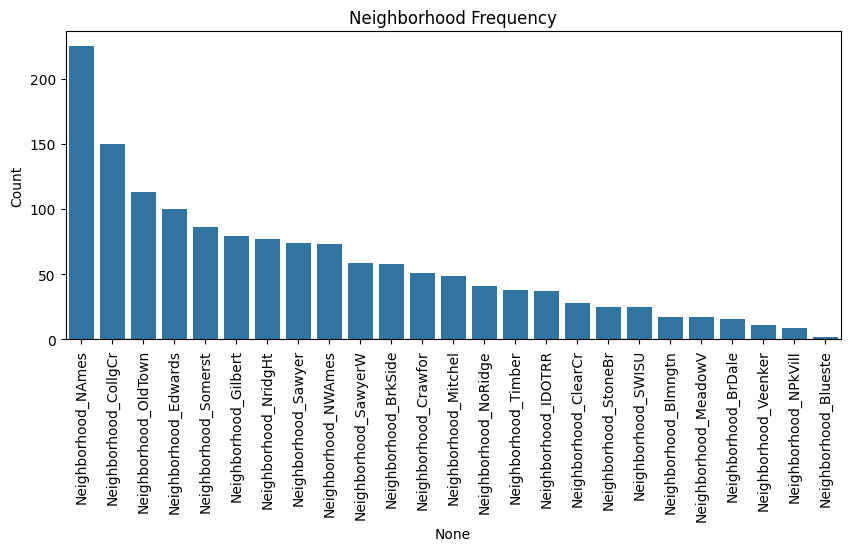

In [64]:
# Visualization: Histograms for continuous/engineered features

continuous_features = [
    'LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'TotalBathrooms', 'Age', 'RemodAge', 'GoodTotalSF', 'TotalSF'
]

for col in continuous_features:
    plt.figure(figsize=(6, 3))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

ordinal_features = [col for col in data.columns if col.endswith('_ord') or col in ['LandContour', 'LandSlope', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Fence', 'Electrical', 'Functional','BldgType']]

# Custom edits to colormap to show 0 "no correlation" as white, and both correlation extremes as equal colors
colors = ["darkred", "firebrick", "orangered", "white", "orangered", "firebrick", "darkred"]
nodes = [0.0, 0.15, 0.25, 0.5, 0.75, 0.85, 1.0]
double_prawn = mcolors.LinearSegmentedColormap.from_list("double_prawn", list(zip(nodes, colors)))
fit_colors = mcolors.TwoSlopeNorm(vmin=-1.0, vcenter=0, vmax=1.0)
corr_cols = [col for col in continuous_features + ordinal_features if col in data.columns]
plt.figure(figsize=(25, 20))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt='.2f', cmap=double_prawn, norm=fit_colors)
plt.title('Correlation Heatmap of Everything')
plt.show()

onehot_cols = [col for col in data.columns if col.startswith('Neighborhood_')]
if onehot_cols:
    neighborhood_counts = data[onehot_cols].sum().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=neighborhood_counts.index, y=neighborhood_counts.values)
    plt.xticks(rotation=90)
    plt.title('Neighborhood Frequency')
    plt.ylabel('Count')
    plt.show()

In [65]:
# Axis Prep
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import time
from tabulate import tabulate

# Set 'SalePrice' as y
y = data['SalePrice'] if 'SalePrice' in data.columns else None
X = data.drop(columns=['SalePrice']) if 'SalePrice' in data.columns else data.copy()


if y is not None:
    # Impute missing values (if any)
    imputer = SimpleImputer(strategy='most_frequent')
    X_imputed = imputer.fit_transform(X)
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    # Train/test split
    X_train_hierarchical, X_test_hierarchical, y_train_hierarchical, y_test_hierarchical = train_test_split(X_scaled, y.values, test_size=0.2, random_state=1234)

    X_total = X_train_hierarchical
    y_total = y_train_hierarchical

    X_train, X_test, y_train, y_test = train_test_split(X_total, y_total, test_size=0.2, random_state=1234)



In [66]:
torch.manual_seed(50) # this makes results reproducable

# If using a GPU, use option 1, if not, use option 2.
 # (If we using GPU, we need to place the class we defined to be put onto the GPU)

# 1
# this says " if there is a GPU, make sure my model can be used on the GPU"
# "if a GPU is not available, then use the CPU"

# 2
#model = mynetwork()

#training settings
batch_size = 100
num_epochs = 500
learning_rate = 1e-3
criterion = nn.MSELoss()

# print interval during the training
print_interval=100

# what this does is save the actual gpu device to a variable.
# in the next cell, we will use this `device` variable
# to say "make my data compatable with my model if it is on the GPU"


In [67]:
def train(training_inputs, training_outputs, network, epochs, learning_rate,
          batch_size, loss_function, print_interval):
  """
  Trains a neural network model using the specified parameters.

  Args:
      training_inputs (numpy.ndarray): Input data (features) for training.
      training_outputs (numpy.ndarray): Target outputs (labels) for training.
      network (torch.nn.Module): The neural network model to be trained.
      epochs (int): Number of training epochs.
      learning_rate (float): Learning rate for optimization.
      batch_size (int): Batch size for mini-batch gradient descent.
      loss_function (torch.nn.Module): Loss function for optimization.
      print_interval (int): Interval for printing training progress.

  Returns:
      None
  """
  train_dataset = torch.utils.data.TensorDataset(torch.from_numpy(training_inputs).float(),
                                                 torch.from_numpy(training_outputs).float())

  train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                             shuffle=True)

  optimizer = torch.optim.Adam(network.parameters(), lr=learning_rate, weight_decay=1e-5)
  track_losses = np.zeros(epochs)

  start = time.time()

  # here is the main part of the training procedure.
  for epoch in range(1, epochs+1):
      for batch_idx, (X, y) in enumerate(train_loader):
          # grab the x's for this batch
          data = X

          data = data.to(DEVICE)

          # find the predictions f(x) for this batch using the forward() method
          output = network.forward(data)

          # find the loss. This calculates MSE using the pytorch version of MSE
          # ('criterion` in previous cell)
          loss = loss_function(output, y.view([-1, 1]).to(DEVICE))

          optimizer.zero_grad()

          # "calculate the gradients for the model parameters"
          loss.backward()

          # "add the gradients to the model parameters"
          optimizer.step()

      # housekeeping - keep track of our losses and print them as we go
      training_loss = loss.item()**.5
      track_losses[epoch-1] = training_loss
      if epoch % print_interval == 0:
          print('epoch: %4d training loss:%10.3e time:%7.1f'%(epoch, training_loss, time.time()-start))

  return network, track_losses

In [68]:
def model_eva(XTrain,XTest,yTrain,yTest,model):
  """
  Evaluates a machine learning model's performance on training and test data.

  Args:
    XTrain (numpy.ndarray): Training input features.
    XTest (numpy.ndarray): Test input features.
    yTrain (numpy.ndarray): Actual training target values.
    yTest (numpy.ndarray): Actual test target values.
    model (torch.nn.Module): Trained PyTorch model.

  Returns:
    tuple: A tuple containing the following evaluation metrics:
    - MAE_train (float): Mean Absolute Error on the training set.
    - MSE_train (float): Mean Squared Error on the training set.
    - RMSE_train (float): Root Mean Squared Error on the training set.
    - R2_train (float): R-squared (coefficient of determination) on the training set.
    - MAE_test (float): Mean Absolute Error on the test set.
    - MSE_test (float): Mean Squared Error on the test set.
    - RMSE_test (float): Root Mean Squared Error on the test set.
    - R2_test (float): R-squared (coefficient of determination) on the test set.
  """
  # since we have placed our model onto the gpu, we must also ensure that the
  # inputs to the model are also compatable with the gpu, so we manually tell
  # pytorch to make a new Tensor from our numpy array, and add the .cuda() to
  # ensure that this new tensor is GPU-compatable.
  XTrain_th = torch.from_numpy(XTrain).float().to(DEVICE)
  XTest_th = torch.from_numpy(XTest).float().to(DEVICE)
  #yTrain_th=torch.Tensor(yTrain).cuda()
  #yTest_th=torch.Tensor(yTest).cuda()

  # get predictions on the training set
  yTrain_pred = model.forward(XTrain_th)

  # since we are using sklearn functions, these must be numpy arrays,
  # so we manually change them from torch.Tensors to np.ndarray's
  yTrain_pred_np = yTrain_pred.cpu().detach().numpy().reshape(-1)

  yTest_pred = model.forward(XTest_th)
  yTest_pred_np = yTest_pred.cpu().detach().numpy().reshape(-1)

  MAE_train=mean_absolute_error(yTrain_pred_np,yTrain)
  MSE_train=mean_squared_error(yTrain_pred_np,yTrain)
  RMSE_train=np.sqrt(mean_squared_error(yTrain_pred_np,yTrain))
  R2_train=r2_score(yTrain_pred_np,yTrain)

  MAE_test=mean_absolute_error(yTest_pred_np,yTest)
  MSE_test=mean_squared_error(yTest_pred_np,yTest)
  RMSE_test=np.sqrt(mean_squared_error(yTest_pred_np,yTest))
  R2_test=r2_score(yTest_pred_np,yTest)

  return MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test

In [69]:
if torch.cuda.is_available():
    print('CUDA available')
    print(torch.cuda.get_device_name(0))
else:
    print('CUDA *not* available')


CUDA available
NVIDIA A100-SXM4-80GB


In [70]:
X_train.shape[1]

217

In [71]:
class mynetwork_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(X_train.shape[1],100),
            nn.ReLU(), # this is a different type of activation function
            nn.Linear(100,80),
            nn.ReLU(),
            nn.Linear(80,50),
            nn.ReLU(), # But what is the key difference?
            nn.Linear(50,1)
        )

    def forward(self, x):
        x = self.structure(x)
        return x

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_1 = mynetwork_1().to(DEVICE)

In [72]:
batch_size = 100
num_epochs = 2000
learning_rate = 1e-2
criterion = nn.MSELoss()

network_1, losses = train(X_train, y_train, model_1, num_epochs, learning_rate, batch_size, criterion, print_interval)


epoch:  100 training loss: 1.179e+04 time:    2.4
epoch:  200 training loss: 3.648e+03 time:    4.7
epoch:  300 training loss: 2.348e+03 time:    7.1
epoch:  400 training loss: 1.351e+03 time:    9.5
epoch:  500 training loss: 1.290e+03 time:   11.8
epoch:  600 training loss: 3.204e+03 time:   14.1
epoch:  700 training loss: 1.227e+03 time:   16.6
epoch:  800 training loss: 1.466e+03 time:   19.0
epoch:  900 training loss: 1.870e+03 time:   21.3
epoch: 1000 training loss: 1.584e+03 time:   23.6
epoch: 1100 training loss: 7.568e+02 time:   25.9
epoch: 1200 training loss: 1.251e+03 time:   28.3
epoch: 1300 training loss: 6.392e+02 time:   30.6
epoch: 1400 training loss: 4.795e+02 time:   33.0
epoch: 1500 training loss: 4.981e+02 time:   35.4
epoch: 1600 training loss: 1.065e+03 time:   37.7
epoch: 1700 training loss: 1.644e+03 time:   40.1
epoch: 1800 training loss: 1.035e+03 time:   42.5
epoch: 1900 training loss: 2.377e+02 time:   44.8
epoch: 2000 training loss: 3.588e+02 time:   47.1


In [73]:
MAE_train_nn1,MSE_train_nn1,RMSE_train_nn1,R2_train_nn1,MAE_test_nn1,MSE_test_nn1,RMSE_test_nn1,R2_test_nn1 = model_eva(X_train,X_test,y_train,y_test,network_1)
results = []

results.append(["NN_1",MAE_train_nn1,MSE_train_nn1,RMSE_train_nn1,R2_train_nn1,MAE_test_nn1,MSE_test_nn1,RMSE_test_nn1,R2_test_nn1])

print(tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],tablefmt="grid"))

+---------+----------------+----------------+-----------------+----------------+------------+-------------+-------------+------------+
| Model   |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Test MAE |    Test MSE |   Test RMSE |   Test R^2 |
+=========+================+================+=================+================+============+=============+=============+============+
| NN_1    |        326.536 |         198618 |         445.666 |        0.99997 |    21507.6 | 8.61039e+08 |     29343.5 |   0.870971 |
+---------+----------------+----------------+-----------------+----------------+------------+-------------+-------------+------------+


In [74]:
class mynetwork_tuna(nn.Module):
    def __init__(self, activation_function):
        super().__init__()
        self.activation = activation_function
        self.structure = nn.Sequential(
            nn.Linear(X_train.shape[1],100),
            self.activation,
            nn.Linear(100,80),
            self.activation,
            nn.Linear(80,50),
            self.activation,
            nn.Linear(50,1)
        )

    # Required forward() fcn, don't fully understand why it is important
    def forward(self, x):
        x = self.structure(x)
        return x

In [79]:
# OPTUNA SWEEP CODE - BEWARE THE TUNA IS A SLOW FISH:

# Network information:
network_act_fcn = nn.LeakyReLU()
network_name    = "NN_TUNA_v2"
network_rotated = mynetwork_tuna(activation_function=network_act_fcn).to(DEVICE) # DEVICE code already defaults to Cuda if available, see sample code

# Training settings:
batch_size = [200, 1000]
num_epochs = [3000,7000] # lower and upper bounds for sweep
learning_rate = [1e-5,1e-2] # lower and upper bounds for sweep
criterion = nn.MSELoss()
print_interval= 100
best_score = np.inf # default value of best performance is infinity
best_network = None
best_hyperparams = {}
num_tuna_trials = 12

#best params: Final best score: 63.27265930175781
# {'epochs': 4307, 'learning_rate': 0.006974455152304111, 'batch_size': 200}

# Data setup:
X_train_tuna, X_test_tuna, y_train_tuna, y_test_tuna = train_test_split(X_train.copy(), y_train.copy(), test_size=0.2, random_state=1234)

# Validation set:
X_test_val  = X_test.copy()
y_test_val  = y_test.copy()

def objective(trial: tuna.Trial):
    hyperparams = {
        "epochs": trial.suggest_int("num_epochs", num_epochs[0], num_epochs[1]),
        "learning_rate": trial.suggest_float("learning_rate", learning_rate[0], learning_rate[1]),
        "batch_size": trial.suggest_int("batch_size", batch_size[0], batch_size[1])
    }
    print(hyperparams)

    global best_score, best_network, best_hyperparams
    network_temporal = copy.deepcopy(network_rotated)
    network_temporal, losses = train(**hyperparams, network=network_temporal, training_inputs= X_train_tuna, training_outputs= y_train_tuna, loss_function=criterion, print_interval=print_interval)
    eval_metrics = model_eva(X_train_tuna, X_test_tuna, y_train_tuna, y_test_tuna, network_temporal)
    print(eval_metrics)
    if eval_metrics[5] < best_score:
        best_score = eval_metrics[5]
        best_network = network_temporal
        best_hyperparams = hyperparams
    
    return eval_metrics[0]

def search_models():
    study = tuna.create_study(direction= "minimize")
    study.optimize(objective, n_trials=num_tuna_trials)
    print(f"Final best score: {best_score}")
    print(best_hyperparams)

# Where the Tuna is unleashed:
search_models()

# Check to make sure results for
if any(network_name in sublist for sublist in results):
    # results = [row for row in results if row[0] != network_name] # in-case removal is required during debugging
    MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test = model_eva(X_train_tuna,X_test_val, y_train_tuna, y_test_val,best_network)
    results.append([network_name,MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test]) 
else: 
    MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test = model_eva(X_train_tuna,X_test_val, y_train_tuna, y_test_val,best_network)
    results.append([network_name,MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test])

# Adding to the results table:
print(tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],tablefmt="grid"))

[I 2026-04-17 03:15:28,776] A new study created in memory with name: no-name-1c07d3b3-7ae8-4733-a1d7-4fe960e409c8


{'epochs': 3159, 'learning_rate': 0.005812647354804205, 'batch_size': 856}
epoch:  100 training loss: 4.150e+04 time:    1.2
epoch:  200 training loss: 2.357e+04 time:    1.8
epoch:  300 training loss: 1.746e+04 time:    2.5
epoch:  400 training loss: 1.446e+04 time:    3.2
epoch:  500 training loss: 1.265e+04 time:    3.8
epoch:  600 training loss: 1.135e+04 time:    4.5
epoch:  700 training loss: 1.036e+04 time:    5.2
epoch:  800 training loss: 9.552e+03 time:    5.8
epoch:  900 training loss: 8.853e+03 time:    6.5
epoch: 1000 training loss: 8.201e+03 time:    7.7
epoch: 1100 training loss: 7.591e+03 time:    8.3
epoch: 1200 training loss: 7.009e+03 time:    9.0
epoch: 1300 training loss: 6.439e+03 time:    9.7
epoch: 1400 training loss: 5.930e+03 time:   10.4
epoch: 1500 training loss: 5.464e+03 time:   11.5
epoch: 1600 training loss: 5.017e+03 time:   12.2
epoch: 1700 training loss: 4.590e+03 time:   12.8
epoch: 1800 training loss: 4.193e+03 time:   13.5
epoch: 1900 training loss

[I 2026-04-17 03:15:52,898] Trial 0 finished with value: 287.2359313964844 and parameters: {'num_epochs': 3159, 'learning_rate': 0.005812647354804205, 'batch_size': 856}. Best is trial 0 with value: 287.2359313964844.


(287.2359313964844, 548321.6875, np.float64(740.4874661329521), 0.9999109506607056, 31609.5234375, 3920122368.0, np.float64(62610.88058796171), 0.6244054436683655)
{'epochs': 6760, 'learning_rate': 0.0035830489393521006, 'batch_size': 268}
epoch:  100 training loss: 2.847e+04 time:    1.0
epoch:  200 training loss: 1.965e+04 time:    2.1
epoch:  300 training loss: 1.173e+04 time:    3.1
epoch:  400 training loss: 8.217e+03 time:    4.2
epoch:  500 training loss: 1.057e+04 time:    5.2
epoch:  600 training loss: 8.421e+03 time:    6.3
epoch:  700 training loss: 6.410e+03 time:    7.3
epoch:  800 training loss: 6.322e+03 time:    8.3
epoch:  900 training loss: 5.806e+03 time:    9.8
epoch: 1000 training loss: 5.423e+03 time:   10.8
epoch: 1100 training loss: 2.171e+03 time:   11.9
epoch: 1200 training loss: 2.687e+03 time:   12.9
epoch: 1300 training loss: 1.650e+03 time:   13.9
epoch: 1400 training loss: 1.638e+03 time:   15.0
epoch: 1500 training loss: 1.474e+03 time:   16.0
epoch: 160

[I 2026-04-17 03:17:05,393] Trial 1 finished with value: 189.89111328125 and parameters: {'num_epochs': 6760, 'learning_rate': 0.0035830489393521006, 'batch_size': 268}. Best is trial 1 with value: 189.89111328125.


...

(161.61830139160156, 72525.578125, np.float64(269.30573355389225), 0.9999882578849792, 29502.13671875, 3535933952.0, np.float64(59463.71962802193), 0.6567603349685669)
{'epochs': 5735, 'learning_rate': 0.0003463037740524958, 'batch_size': 959}
epoch:  100 training loss: 1.977e+05 time:    1.2
epoch:  200 training loss: 1.961e+05 time:    1.8
epoch:  300 training loss: 1.874e+05 time:    2.5
epoch:  400 training loss: 1.635e+05 time:    3.1
epoch:  500 training loss: 1.237e+05 time:    3.8
epoch:  600 training loss: 8.867e+04 time:    4.5
epoch:  700 training loss: 7.255e+04 time:    5.1
epoch:  800 training loss: 6.313e+04 time:    5.8
epoch:  900 training loss: 5.592e+04 time:    6.4
epoch: 1000 training loss: 5.047e+04 time:    7.1
epoch: 1100 training loss: 4.642e+04 time:    8.3
epoch: 1200 training loss: 4.337e+04 time:    8.9
epoch: 1300 training loss: 4.094e+04 time:    9.6
epoch: 1400 training loss: 3.892e+04 time:   10.3
epoch: 1500 training loss: 3.713e+04 time:   10.9
epoch:

[I 2026-04-17 03:24:34,105] Trial 10 finished with value: 7110.4912109375 and parameters: {'num_epochs': 5735, 'learning_rate': 0.0003463037740524958, 'batch_size': 959}. Best is trial 4 with value: 12.934911727905273.


(7110.4912109375, 141965424.0, np.float64(11914.924422756529), 0.9763829112052917, 33382.3203125, 3657189632.0, np.float64(60474.702413488565), 0.5776657462120056)
{'epochs': 5637, 'learning_rate': 0.0073261912810980035, 'batch_size': 977}
epoch:  100 training loss: 3.541e+04 time:    0.7
epoch:  200 training loss: 2.086e+04 time:    1.8
epoch:  300 training loss: 1.560e+04 time:    2.5
epoch:  400 training loss: 1.294e+04 time:    3.7
epoch:  500 training loss: 1.128e+04 time:    4.3
epoch:  600 training loss: 1.008e+04 time:    5.0
epoch:  700 training loss: 9.121e+03 time:    5.7
epoch:  800 training loss: 8.293e+03 time:    6.3
epoch:  900 training loss: 7.517e+03 time:    7.0
epoch: 1000 training loss: 6.821e+03 time:    7.6
epoch: 1100 training loss: 6.160e+03 time:    8.3
epoch: 1200 training loss: 5.530e+03 time:    9.0
epoch: 1300 training loss: 4.910e+03 time:    9.6
epoch: 1400 training loss: 4.344e+03 time:   10.8
epoch: 1500 training loss: 3.824e+03 time:   11.5
epoch: 160

[I 2026-04-17 03:25:17,043] Trial 11 finished with value: 15.095653533935547 and parameters: {'num_epochs': 5637, 'learning_rate': 0.0073261912810980035, 'batch_size': 977}. Best is trial 4 with value: 12.934911727905273.


(15.095653533935547, 16388.81640625, np.float64(128.01881270442246), 0.9999973177909851, 31620.603515625, 3666001152.0, np.float64(60547.511526073475), 0.6254183053970337)
Final best score: 3393117952.0
{'epochs': 6394, 'learning_rate': 0.004628348262014739, 'batch_size': 728}
+------------+----------------+------------------+-----------------+----------------+------------+-------------+-------------+------------+
| Model      |   Training MAE |     Training MSE |   Training RMSE |   Training R^2 |   Test MAE |    Test MSE |   Test RMSE |   Test R^2 |
+============+================+==================+=================+================+============+=============+=============+============+
| NN_1       |       326.536  | 198618           |         445.666 |       0.99997  |    21507.6 | 8.61039e+08 |     29343.5 |   0.870971 |
+------------+----------------+------------------+-----------------+----------------+------------+-------------+-------------+------------+
| NN_TUNA    |        